# plots 

In [2]:
# setup imports
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[3]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from ewatercycle.observation.grdc import get_grdc_data

from src.paths import *

In [3]:
PATH_TO_DATA = Path(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/test_shapefiles_all_data"
)

In [4]:
scenario_1_path = PATH_TO_DATA / "pcrglobwb_20260121_131858" / "netcdf"
scenario_2_path = PATH_TO_DATA / "pcrglobwb_20260121_140359" / "netcdf"
scenario_3_path = PATH_TO_DATA / "pcrglobwb_20260121_144633" / "netcdf"

In [5]:
Kerki_station_latitude = 37.8396310038444  # Amu Darya near Kerki
Kerki_station_longitude = 65.23703868931334


TA_station_latitude = 43.95
TA_station_longitude = 67.05

In [10]:
nc_files = sorted(scenario_1_path.glob("*.nc"))

# filenames only (as strings)
nc_filenames = [p.name for p in nc_files]


print(f"{'Index':<5} {'Filename':<30} {'Size (MB)':>10}")
print("-" * 50)

for i, f in enumerate(nc_files, start=0):  # start index at 0
    size_mb = f.stat().st_size / (1024 * 1024)  # convert bytes to MB
    print(f"{i:<5} {f.name:<30} {size_mb:>10.2f}")

Index Filename                        Size (MB)
--------------------------------------------------
0     channelStorage_dailyTot_output.nc      97.62
1     discharge_dailyTot_output.nc        99.39
2     domesticWaterWithdrawal_dailyTot_output.nc      23.99
3     dynamicFracWat_dailyTot_output.nc     101.44
4     evaporation_from_irrigation_dailyTot_output.nc      28.94
5     gwRecharge_dailyTot_output.nc      110.11
6     industryWaterWithdrawal_dailyTot_output.nc      16.30
7     interceptStor_dailyTot_output.nc       2.51
8     irrPaddyWaterWithdrawal_dailyTot_output.nc       7.11
9     nonIrrGrossDemand_dailyTot_output.nc      24.87
10    nonIrrWaterConsumption_dailyTot_output.nc      24.88
11    precipitation_at_irrigation_dailyTot_output.nc      12.20
12    precipitation_dailyTot_output.nc      31.72
13    snowCoverSWE_dailyTot_output.nc      42.07
14    snowFreeWater_dailyTot_output.nc      10.77
15    storGroundwater_dailyTot_output.nc     128.39
16    storLowTotal_dailyTot_out

In [27]:
scenario_paths = [scenario_1_path, scenario_2_path, scenario_3_path]

# Scenario names
scenario_names = ["full basin", "subset", "slice with buffer"]

# Output folders
combined_folder = Path(PATH_TO_DATA / "plots/combined")
individual_folder = Path(PATH_TO_DATA / "plots/individual")
combined_folder.mkdir(parents=True, exist_ok=True)
individual_folder.mkdir(parents=True, exist_ok=True)

# Assume all scenarios have same filenames
nc_files = sorted(scenario_paths[0].glob("*.nc"))
nc_filenames = [f.name for f in nc_files]

# User selection
selected_variable = None  # None -> take first variable in file
selected_time_index = 1  # last timestep (can adjust)

# Loop over all files
for selected_index, nc_filename in enumerate(nc_filenames):
    # Load scenario 1 to get extent
    scen1_file = scenario_paths[0] / nc_filename
    ds1 = xr.open_dataset(scen1_file)
    var_to_plot = selected_variable or list(ds1.data_vars)[0]

    # Get lat/lon extent from scenario 1
    lon_min, lon_max = ds1["lon"].min().item(), ds1["lon"].max().item()
    lat_min, lat_max = ds1["lat"].min().item(), ds1["lat"].max().item()

    # --- Combined subplot figure ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    for ax, scen_name, scen_path in zip(axes, scenario_names, scenario_paths):
        selected_file = scen_path / nc_filename
        ds = xr.open_dataset(selected_file)

        ds[var_to_plot].isel(time=selected_time_index).plot(
            ax=ax, x="lon", y="lat", cmap="viridis", add_colorbar=True
        )
        ax.set_title(scen_name)
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)

    plt.suptitle(f"{var_to_plot} at timestep {selected_time_index}", fontsize=16)

    # Save combined figure
    combined_path = (
        combined_folder / f"{nc_filename.replace('.nc','')}_t{selected_time_index}_combined.png"
    )
    plt.savefig(combined_path, dpi=200)
    plt.close(fig)
    print(f"Saved combined figure for {nc_filename} -> {combined_path}")

    # --- Save individual figures ---
    for scen_name, scen_path in zip(scenario_names, scenario_paths):
        selected_file = scen_path / nc_filename
        ds = xr.open_dataset(selected_file)

        fig, ax = plt.subplots(figsize=(6, 5))
        ds[var_to_plot].isel(time=selected_time_index).plot(
            ax=ax, x="lon", y="lat", cmap="viridis", add_colorbar=True
        )
        ax.set_title(f"{scen_name}: {var_to_plot}")
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)

        indiv_path = (
            individual_folder
            / f"{nc_filename.replace('.nc','')}_t{selected_time_index}_{scen_name.replace(' ','_')}.png"
        )
        plt.savefig(indiv_path, dpi=200)
        plt.close(fig)
        print(f"Saved individual figure for {scen_name} -> {indiv_path}")

Saved combined figure for channelStorage_dailyTot_output.nc -> /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/test_shapefiles_all_data/plots/combined/channelStorage_dailyTot_output_t1_combined.png
Saved individual figure for full basin -> /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/test_shapefiles_all_data/plots/individual/channelStorage_dailyTot_output_t1_full_basin.png
Saved individual figure for subset -> /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/test_shapefiles_all_data/plots/individual/channelStorage_dailyTot_output_t1_subset.png
Saved individual figure for slice with buffer -> /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_

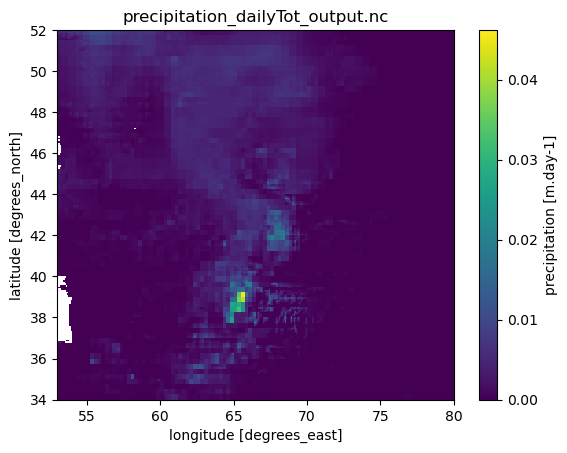

In [15]:
# variable1 = Path(scenario_1_path/nc_filenames[])
# scenario1_swe = Path(scenario_1_path/"snowCoverSWE_dailyTot_output.nc")


# ds_1_q = xr.open_dataset(scenario1_q)
# ds_1_swe = xr.open_dataset(scenario1_swe)


# plt.figure()
# ds_1_q['discharge'].isel(time=-150).plot()

# plt.figure()
# ds_1_swe['snow_water_equivalent'].isel(time=-150).plot()
# #


# da_2riv_a=ds_2riv['discharge'].isel(time=-150)

# Select file and variable to plot
selected_index = 12
selected_variable = None


# Open selected file
selected_file = nc_files[selected_index]
ds = xr.open_dataset(selected_file)

# Determine variable to plot
if selected_variable is None:
    selected_variable = list(ds.data_vars)[0]  # take the first variable

# Plot a snapshot (e.g., last time step)
plt.figure()
ds[selected_variable].isel(time=-1).plot()
plt.title(f"{selected_file.name}")
plt.show()

In [27]:
def load_scenario_variable(
    scenario_path: Path,
    filename: str,
    variable_name: str,
) -> xr.DataArray:
    """
    Load a single variable from a scenario NetCDF file.

    Returns
    -------
    xarray.DataArray
    """
    file_path = scenario_path / filename
    ds = xr.open_dataset(file_path)
    return ds[variable_name]

In [28]:
def load_variable_for_scenarios(
    scenario_paths: dict[str, Path],
    filename: str,
    variable_name: str,
) -> dict[str, xr.DataArray]:
    """
    Load the same variable from multiple scenarios.

    Returns
    -------
    dict: {scenario_name: DataArray}
    """
    return {
        name: load_scenario_variable(path, filename, variable_name)
        for name, path in scenario_paths.items()
    }

In [29]:
def plot_spatial_snapshot(
    da: xr.DataArray,
    time_index: int = -1,
    title: str | None = None,
    cmap: str = "viridis",
):
    """
    Plot a spatial field at a single timestep.
    """
    da_t = da.isel(time=time_index)

    plt.figure()
    da_t.plot(cmap=cmap)
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

    return da_t

In [30]:
def extract_station_timeseries(
    da: xr.DataArray,
    latitude: float,
    longitude: float,
    method: str = "nearest",
) -> xr.DataArray:
    """
    Extract a point time series at a station location.
    """
    return da.sel(
        lat=latitude,
        lon=longitude,
        method=method,
    )

In [31]:
def extract_multiple_stations(
    scenario_data: dict[str, xr.DataArray],
    stations: dict[str, tuple[float, float]],
) -> dict[str, dict[str, xr.DataArray]]:
    """
    Returns:
    {scenario: {station: DataArray}}
    """
    return {
        scenario: {
            station: extract_station_timeseries(da, lat, lon)
            for station, (lat, lon) in stations.items()
        }
        for scenario, da in scenario_data.items()
    }

In [32]:
def plot_station_comparison(
    series_dict: dict[str, xr.DataArray],
    title: str,
    y_label: str = "Discharge [m³/s]",
    time_limits: tuple[str, str] | None = None,
    y_limits: tuple[float, float] | None = None,
):
    """
    Plot multiple station time series on one axis.
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    for label, da in series_dict.items():
        da.plot(ax=ax, label=label)

    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel(y_label)
    ax.legend()
    ax.grid(True)

    if time_limits:
        ax.set_xlim(pd.Timestamp(time_limits[0]), pd.Timestamp(time_limits[1]))
    if y_limits:
        ax.set_ylim(*y_limits)

    plt.tight_layout()
    plt.show()

In [33]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from cartopy.feature import ShapelyFeature
from cartopy.io.shapereader import Reader


def plot_discharge_map(
    da: xr.DataArray,
    time_index: int,
    shapefiles: dict[str, dict],
    stations: dict[str, tuple[float, float]],
    # extent: list[float],
    title: str,
    projection=ccrs.Mollweide(central_longitude=69.5),
    cmap: str = "viridis",
):
    """
    Plot a discharge snapshot with shapefiles and stations.
    """
    da_t = da.isel(time=time_index)

    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=projection)

    da_t.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        cbar_kwargs={"label": "Discharge [m³/s]"},
    )

    # Shapefiles
    for label, cfg in shapefiles.items():
        feature = ShapelyFeature(
            Reader(cfg["path"]).geometries(),
            ccrs.PlateCarree(),
            facecolor="none",
            edgecolor=cfg.get("edgecolor", "black"),
            linewidth=cfg.get("linewidth", 1),
            label=label,
        )
        ax.add_feature(feature)

    # Stations
    for name, (lat, lon) in stations.items():
        ax.scatter(
            lon,
            lat,
            s=60,
            marker="o",
            transform=ccrs.PlateCarree(),
            label=name,
            zorder=5,
        )

    # ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines(
        draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle="--", alpha=0.5
    )

    date_str = str(da_t.time.values.astype("M8[D]"))
    ax.set_title(f"{title}\n{date_str}")
    ax.legend()

    plt.tight_layout()
    plt.show()

# actual data

In [34]:
scenario_paths = {
    "full basin": scenario_1_path,
    "2 rivers sharp": scenario_2_path,
    "2 rivers square": scenario_3_path,
    "2 rivers edge": scenario_4_path,
    "2 rivers buffer": scenario_5_path,
}

In [35]:
discharge_all = load_variable_for_scenarios(
    scenario_paths,
    "discharge_dailyTot_output.nc",
    "discharge",
)

swe_all = load_variable_for_scenarios(
    scenario_paths,
    "snowCoverSWE_dailyTot_output.nc",
    "snow_water_equivalent",
)

In [36]:
q_kerki_all = {
    name: extract_station_timeseries(
        da,
        Kerki_station_latitude,
        Kerki_station_longitude,
    )
    for name, da in discharge_all.items()
}

q_TA_all = {
    name: extract_station_timeseries(
        da,
        TA_station_latitude,
        TA_station_longitude,
    )
    for name, da in discharge_all.items()
}

In [37]:
grdc_kerki = get_grdc_data(
    2617110, "1950-01-01T00:00Z", "1950-12-31T00:00Z", data_home=GRDC / "Daily"
)

grdc_TA = get_grdc_data(2316200, "1950-01-01T00:00Z", "1950-12-31T00:00Z", data_home=GRDC / "Daily")

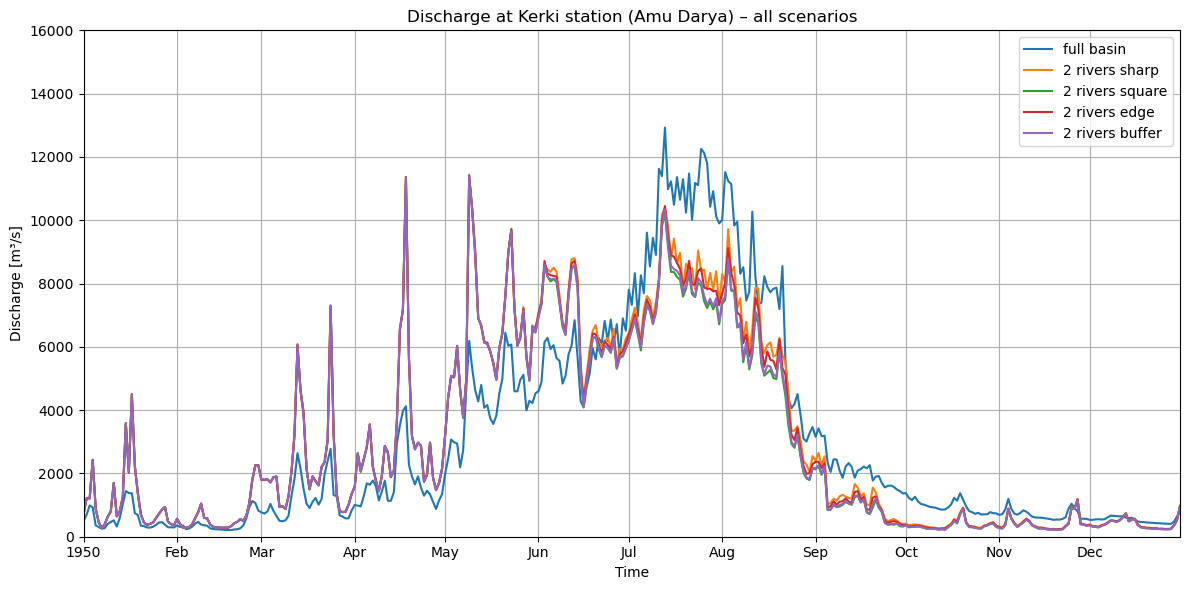

In [38]:
plot_station_comparison(
    series_dict=q_kerki_all,
    title="Discharge at Kerki station (Amu Darya) – all scenarios",
    time_limits=("1950-01-01", "1950-12-31"),
    y_limits=(0, 16000),
)

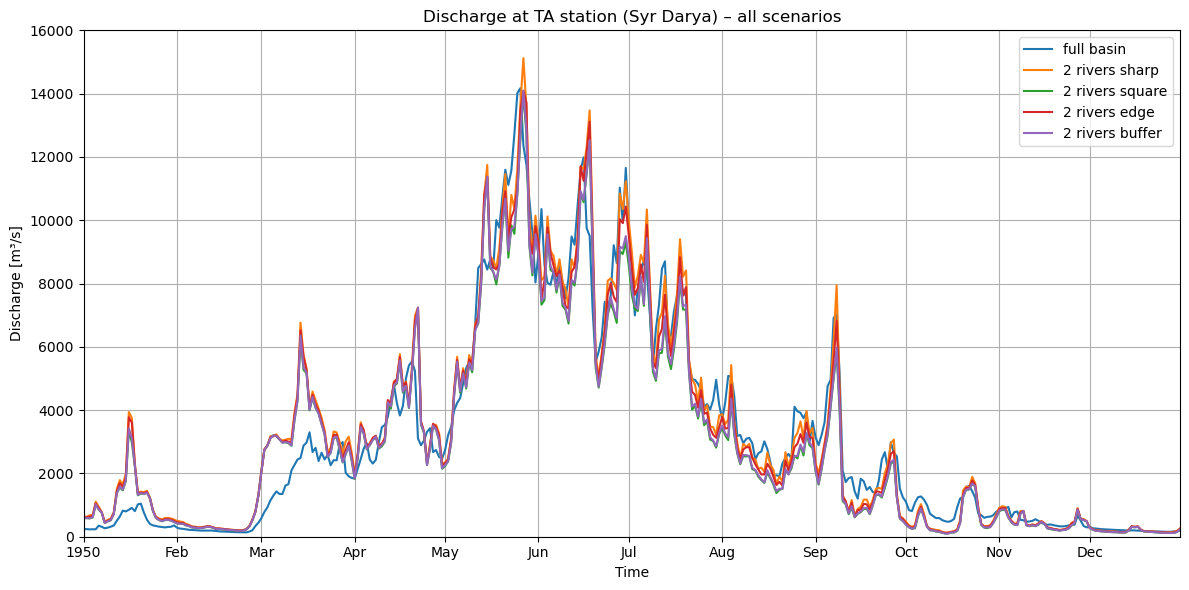

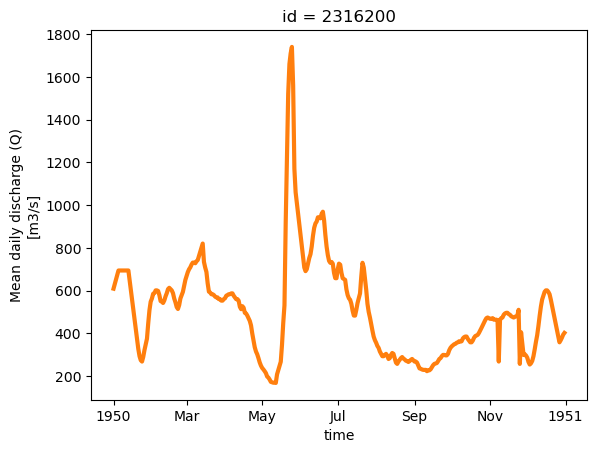

In [39]:
plot_station_comparison(
    series_dict=q_TA_all,
    title="Discharge at TA station (Syr Darya) – all scenarios",
    time_limits=("1950-01-01", "1950-12-31"),
    y_limits=(0, 16000),
)


grdc_TA["streamflow"].plot(label="GRDC", color="tab:orange", linewidth=3, zorder=3)

/tmp/ipykernel_201155/2557290169.py:60: UserWarning: Legend does not support handles for FeatureArtist instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


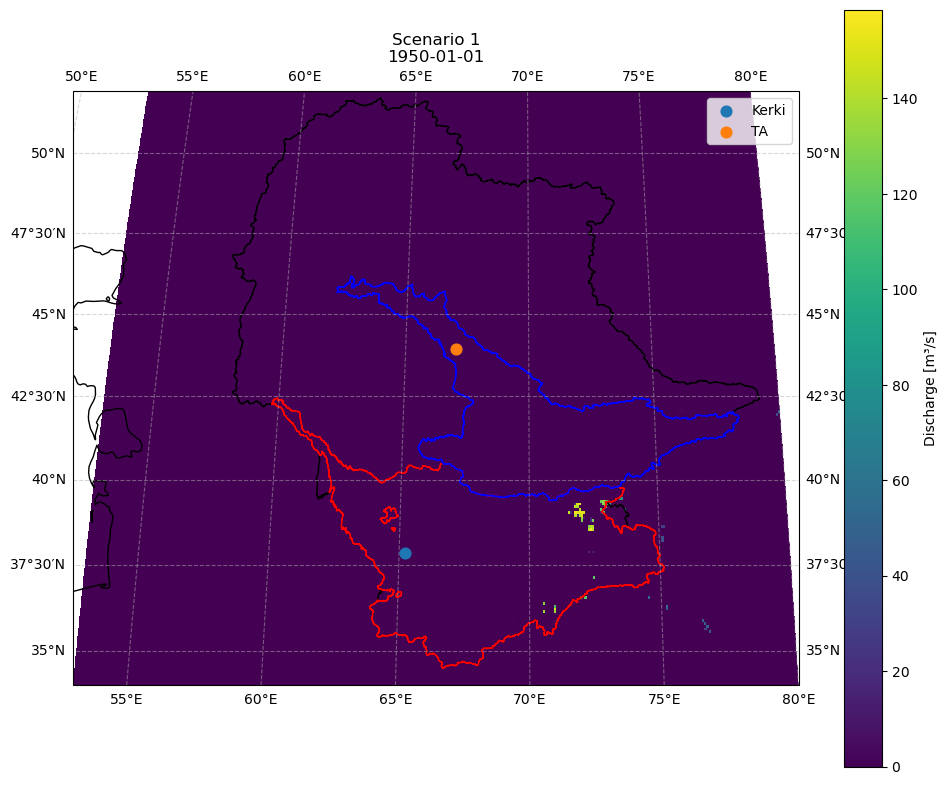

In [ ]:
shapefiles = {
    "Aral Sea basin": {"path": SHAPEFILES / "AralSea_basin/AralSea_basin.shp"},
    "Amu Darya": {
        "path": SHAPEFILES / "Chatly_GRDC/Chatly_GRDC.shp",
        "edgecolor": "red",
    },
    "Syr Darya": {
        "path": SHAPEFILES / "Kazalinsk_GRDC/Kazalinsk_GRDC.shp",
        "edgecolor": "blue",
    },
}

stations = {
    "Kerki": (Kerki_station_latitude, Kerki_station_longitude),
    "TA": (TA_station_latitude, TA_station_longitude),
}

# extent = [59, 64, 39, 43]

plot_discharge_map(
    da=["full basin"],
    time_index=-365,
    shapefiles=shapefiles,
    stations=stations,
    # extent=extent,
    title="Scenario 1",
)

In [41]:
da = swe_all["full basin"].isel(time=-1)

stacked = da.stack(point=("lat", "lon"))
idx = stacked.idxmax(dim="point")

lat_max = idx["lat"].item()
lon_max = idx["lon"].item()

lat_max, lon_max

(38.54166793823242, 72.375)

In [45]:
max_SWE_all = {
    name: extract_station_timeseries(
        da,
        40,
        70,
    )
    for name, da in swe_all.items()
}

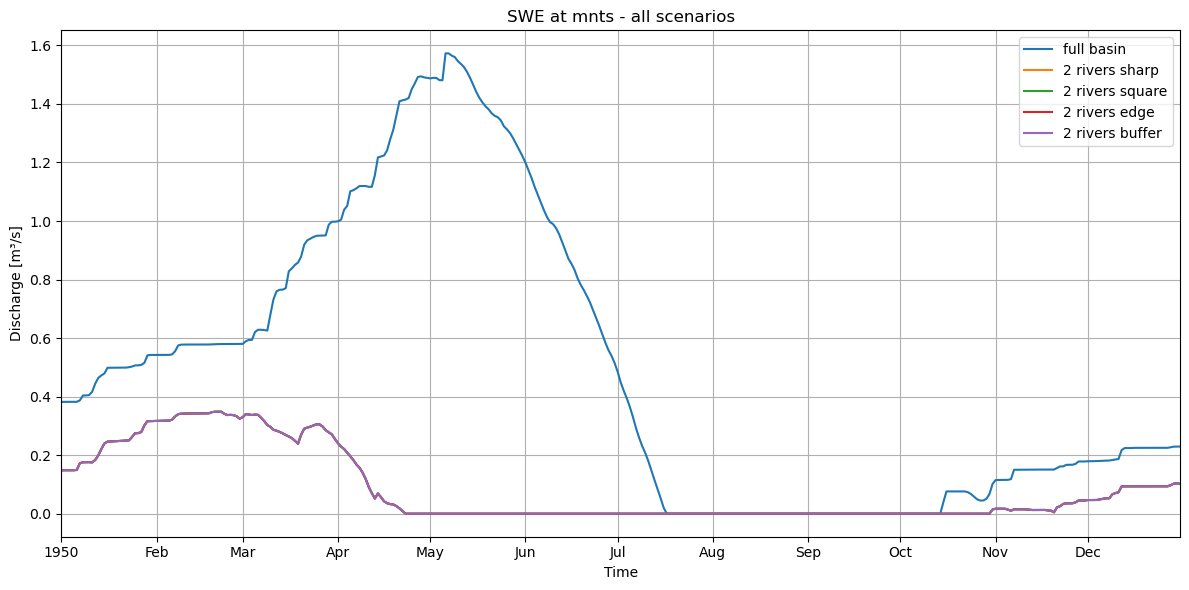

In [46]:
plot_station_comparison(
    series_dict=max_SWE_all,
    title="SWE at mnts - all scenarios",
    time_limits=("1950-01-01", "1950-12-31"),
    # y_limits=(0, 16000),
)

In [47]:
max_SWE_all

{'full basin': <xarray.DataArray 'snow_water_equivalent' (time: 579)> Size: 2kB
 [579 values with dtype=float32]
 Coordinates:
   * time     (time) datetime64[ns] 5kB 1949-06-01 1949-06-02 ... 1950-12-31
     lat      float32 4B 40.04
     lon      float32 4B 70.04
 Attributes:
     standard_name:  snow_water_equivalent
     long_name:      snow_cover_in_water_equivalent_amount
     units:          m,
 '2 rivers sharp': <xarray.DataArray 'snow_water_equivalent' (time: 579)> Size: 2kB
 [579 values with dtype=float32]
 Coordinates:
   * time     (time) datetime64[ns] 5kB 1949-06-01 1949-06-02 ... 1950-12-31
     lat      float32 4B 40.04
     lon      float32 4B 70.04
 Attributes:
     standard_name:  snow_water_equivalent
     long_name:      snow_cover_in_water_equivalent_amount
     units:          m,
 '2 rivers square': <xarray.DataArray 'snow_water_equivalent' (time: 579)> Size: 2kB
 [579 values with dtype=float32]
 Coordinates:
   * time     (time) datetime64[ns] 5kB 1949-06-01 194